In [1]:
words = open("names.txt","r").read().splitlines()

In [2]:
stoi = {ch: i for i,ch in enumerate(sorted(set(".".join(words))))}
itos = {i:ch for ch,i in stoi.items()}

In [3]:
import torch

In [4]:
context = []
context_len = 3
iy = []
for w in words:
    w = w+'.'
    cntxt = [0]*context_len
    for ch in w:
        context.append(cntxt)
        iy.append(stoi[ch])
        cntxt = cntxt[1:] + [stoi[ch]]
context = torch.tensor(context)
iy = torch.tensor(iy)
ix = context
context.shape, iy.shape

(torch.Size([228146, 3]), torch.Size([228146]))

In [44]:
emb_len = 15
cntx_len = 3



In [63]:
import torch

C = torch.rand((27,emb_len)).float()
W1 = torch.randn((emb_len*cntx_len, 300)).float()*(5/3)/torch.sqrt(torch.tensor(emb_len*cntx_len)).item()
b1 = torch.randn((300,)).float() * 0.01

W2 = torch.randn((300, 27)).float()*(5/3)/torch.sqrt(torch.tensor(emb_len*cntx_len)).item()
b2 = torch.randn((27,)).float()*0.01

parameters= [C,W1,W2,b1,b2]

for p in parameters:
    p.requires_grad = True

sum(p.nelement() for p in parameters)

22332

In [49]:
lli = torch.linspace(0,1, 1000)
lossi = []

In [50]:
import torch.nn.functional as F

for i in range(200000):

    batch = torch.randint(0, iy.shape[0], (32,))
    emb = C[ix[batch]]
    h = emb.view(-1,emb_len*cntx_len) @ W1 + b1
    h = torch.tanh(h)

    logits = h @ W2+ b2

    loss = F.cross_entropy(logits, iy[batch])

    for p in parameters:
        p.grad = None
        
    lr = 0.1 if i < 100000 else 0.01
    print(loss.item())
    loss.backward()
    for p in parameters:
        p.data -= lr*p.grad
loss

27.36151885986328
23.684043884277344
16.145627975463867
16.854589462280273
18.186357498168945
18.615190505981445
13.209428787231445
14.013640403747559
11.484991073608398
13.978692054748535
13.904943466186523
11.85999584197998
9.41722297668457
11.607616424560547
13.068894386291504
12.86481761932373
12.167449951171875
11.747477531433105
14.838517189025879
11.254664421081543
11.53252124786377
9.087438583374023
10.723193168640137
10.351733207702637
9.488116264343262
12.608957290649414
8.930334091186523
10.422075271606445
8.235319137573242
9.577354431152344
10.565428733825684
7.729239463806152
9.56735610961914
10.59996509552002
9.441529273986816
8.863070487976074
7.768230438232422
7.761499881744385
9.646472930908203
9.614866256713867
8.088351249694824
7.224460124969482
6.54584264755249
6.959985256195068
6.227081775665283
7.753460884094238
6.715643882751465
7.821366310119629
6.16896390914917
7.178562164306641
5.627554416656494
5.897392749786377
6.446074485778809
6.672926902770996
8.465003967

KeyboardInterrupt: 

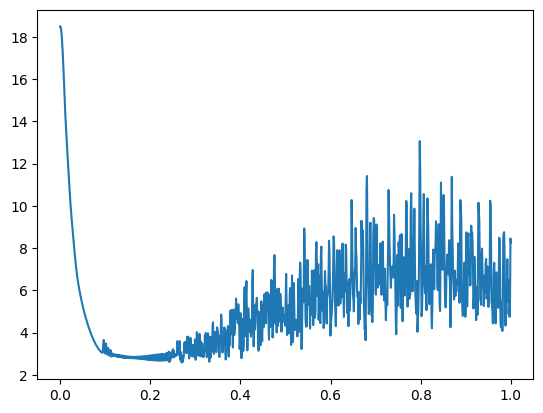

In [31]:
import matplotlib.pyplot as plt

plt.plot(lli, lossi)
plt.show()


In [37]:
with torch.no_grad():
    input = C[ix]

    h = input.view(-1,emb_len*cntx_len)@ W1 + b1
    h = torch.tanh(h)

    logits = h@W2 + b2

    loss = F.cross_entropy(logits, iy)
    print(loss.item())

2.3208670616149902


In [43]:
for i in range(10):
    out  = ""
    cntxt = [0] * cntx_len
    with torch.no_grad():
        while True:
            input = C[cntxt]
            h = input.view(-1,emb_len*cntx_len)@ W1 + b1
            # print(h)
            logits = h@W2 + b2

            prob = torch.softmax(logits, dim = 1)

            ch_int = torch.multinomial(prob, num_samples = 1,).item()
            out += itos [ch_int]

            cntxt = cntxt[1:] + [ch_int]
            if ch_int == 0:
                break

        print(out)

uaaaahaahaahaahaahaahaahaahaahaahaahaahariacia.
uaa.
ruahaahaahaahahaahariahaahaahaahaahaahaahaahaahaahaahaahaaahariacoriacaasuaa.
ruacua.
uaa.
uaaahaahaahaahaahaaaahaahaahaaaahaahaahaahaahaahaahaahaahaahariacia.
uamariaciahaahaahaahaaahaahariahaahaahaahaahaaahaahaahaahaahaahaahaaahaahaahaahaahaaahaahaaharishariacia.
uaa.
uaaaaahariahaaahaahaahaahaahaahaasuaaahaahaaahaahaahariacia.
uaa.
